# Exploratory Data Analysis: Customer Behavioral Features

This notebook performs a deep dive Exploratory Data Analysis (EDA) on the aggregated customer-level features dataset generated in `src/features/features.py`.

## Objectives
1. **Univariate Analysis**: Profile distributions (mean, median, standard deviation, IQR, skewness) of core behavioral features.
2. **Bivariate & Target Correlation**: Measure linear (Pearson) and non-linear (Spearman) relationship with 90-day Churn and CLV targets.
3. **Multicollinearity Diagnostics**: Compute Variance Inflation Factors (VIF) and flag predictors with $VIF > 5.0$.
4. **Country-Level & Seasonal Patterns**: Map customer locations and evaluate seasonal concentration (proportion of Q4 purchases) to differentiate holiday/gift-buyers from year-round habitual shoppers.
5. **Hypothesis Generation**: Formulate testable hypotheses to guide modeling experiments.

## 1. Setup & Data Loading

First, we import the necessary libraries and the reusable functions from our utility module `src.utils.eda_utils`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the root directory to path to import local modules
sys.path.append(os.path.abspath(".."))

from src.utils.eda_utils import (
    calculate_univariate_stats,
    calculate_vif,
    calculate_correlations
)

# Set visual styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

### Load Datasets

We load the processed customer features and map the customer countries from the cleaned interim retail transactions dataset.

In [2]:
df_features = pd.read_csv("../data/processed/(PROC)online_retail_II.csv")
df_clean = pd.read_csv("../data/Interim/(INTERIM)online_retail_II.csv")

# Map country to customer ID (using their most frequent country)
customer_country = df_clean.groupby("customer_id")["country"].agg(lambda x: x.mode()[0]).reset_index()
df_features = df_features.merge(customer_country, on="customer_id", how="left")

print(f"Customer features dataset shape: {df_features.shape}")
df_features.head()

Customer features dataset shape: (5346, 27)


,customer_id,recency,frequency,monetary_total,monetary_avg,avg_basket_size,purchase_frequency_trend,variance_purchase_intervals,seasonal_concentration,return_rate,...,affinity_84879,affinity_21232,affinity_47566,affinity_22197,affinity_22383,engagement_score,target_churn,target_clv,target_next_category,country
0,13085.0,66,10,485.64,48.564000,72.600000,0.0,7233.194444,0.500000,0.130539,...,0.000000,0.049587,0.000000,0.000000,0.000000,0.411642,1,0.00,NONE,United Kingdom
1,13078.0,9,79,22112.19,279.901139,109.594937,2.0,43.581752,0.240506,0.013895,...,0.057288,0.000000,0.000000,0.000000,0.000000,0.511403,0,5608.63,22197,United Kingdom
2,15362.0,357,2,613.08,306.540000,184.000000,0.0,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.225794,1,0.00,NONE,United Kingdom
3,18102.0,7,120,435567.63,3629.730250,1221.116667,0.0,81.430423,0.175000,0.008324,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.785146,0,123737.11,22687,United Kingdom
4,12682.0,9,42,18714.12,445.574286,201.904762,3.0,129.974390,0.190476,0.001060,...,0.000000,0.000000,0.006132,0.011321,0.008255,0.481597,0,4059.90,23390,France


## 2. Univariate Profiling

We compute statistical summaries (mean, median, standard deviation, IQR, skewness) for key spend, recency, order frequency, basket size, and engagement metrics.

In [3]:
cols_uni = ["monetary_total", "monetary_avg", "recency", "frequency", "avg_basket_size", "engagement_score"]
df_uni_stats = calculate_univariate_stats(df_features, cols_uni)
df_uni_stats

,feature,mean,median,std,iqr,skewness
0,monetary_total,2306.917427,715.140000,11340.573475,1616.215000,24.564436
1,monetary_avg,257.231245,219.502500,862.309432,199.818750,-38.240823
2,recency,207.643285,163.000000,177.134049,280.000000,0.665060
3,frequency,6.937897,3.000000,14.157945,7.000000,11.141826
4,avg_basket_size,193.542663,124.000000,1291.257692,139.099679,59.301787
5,engagement_score,0.322835,0.347238,0.114763,0.177077,-0.504619


### Visualizing Distributions

Let's look at the distribution profiles for these variables to understand their skewness and outlier presence.

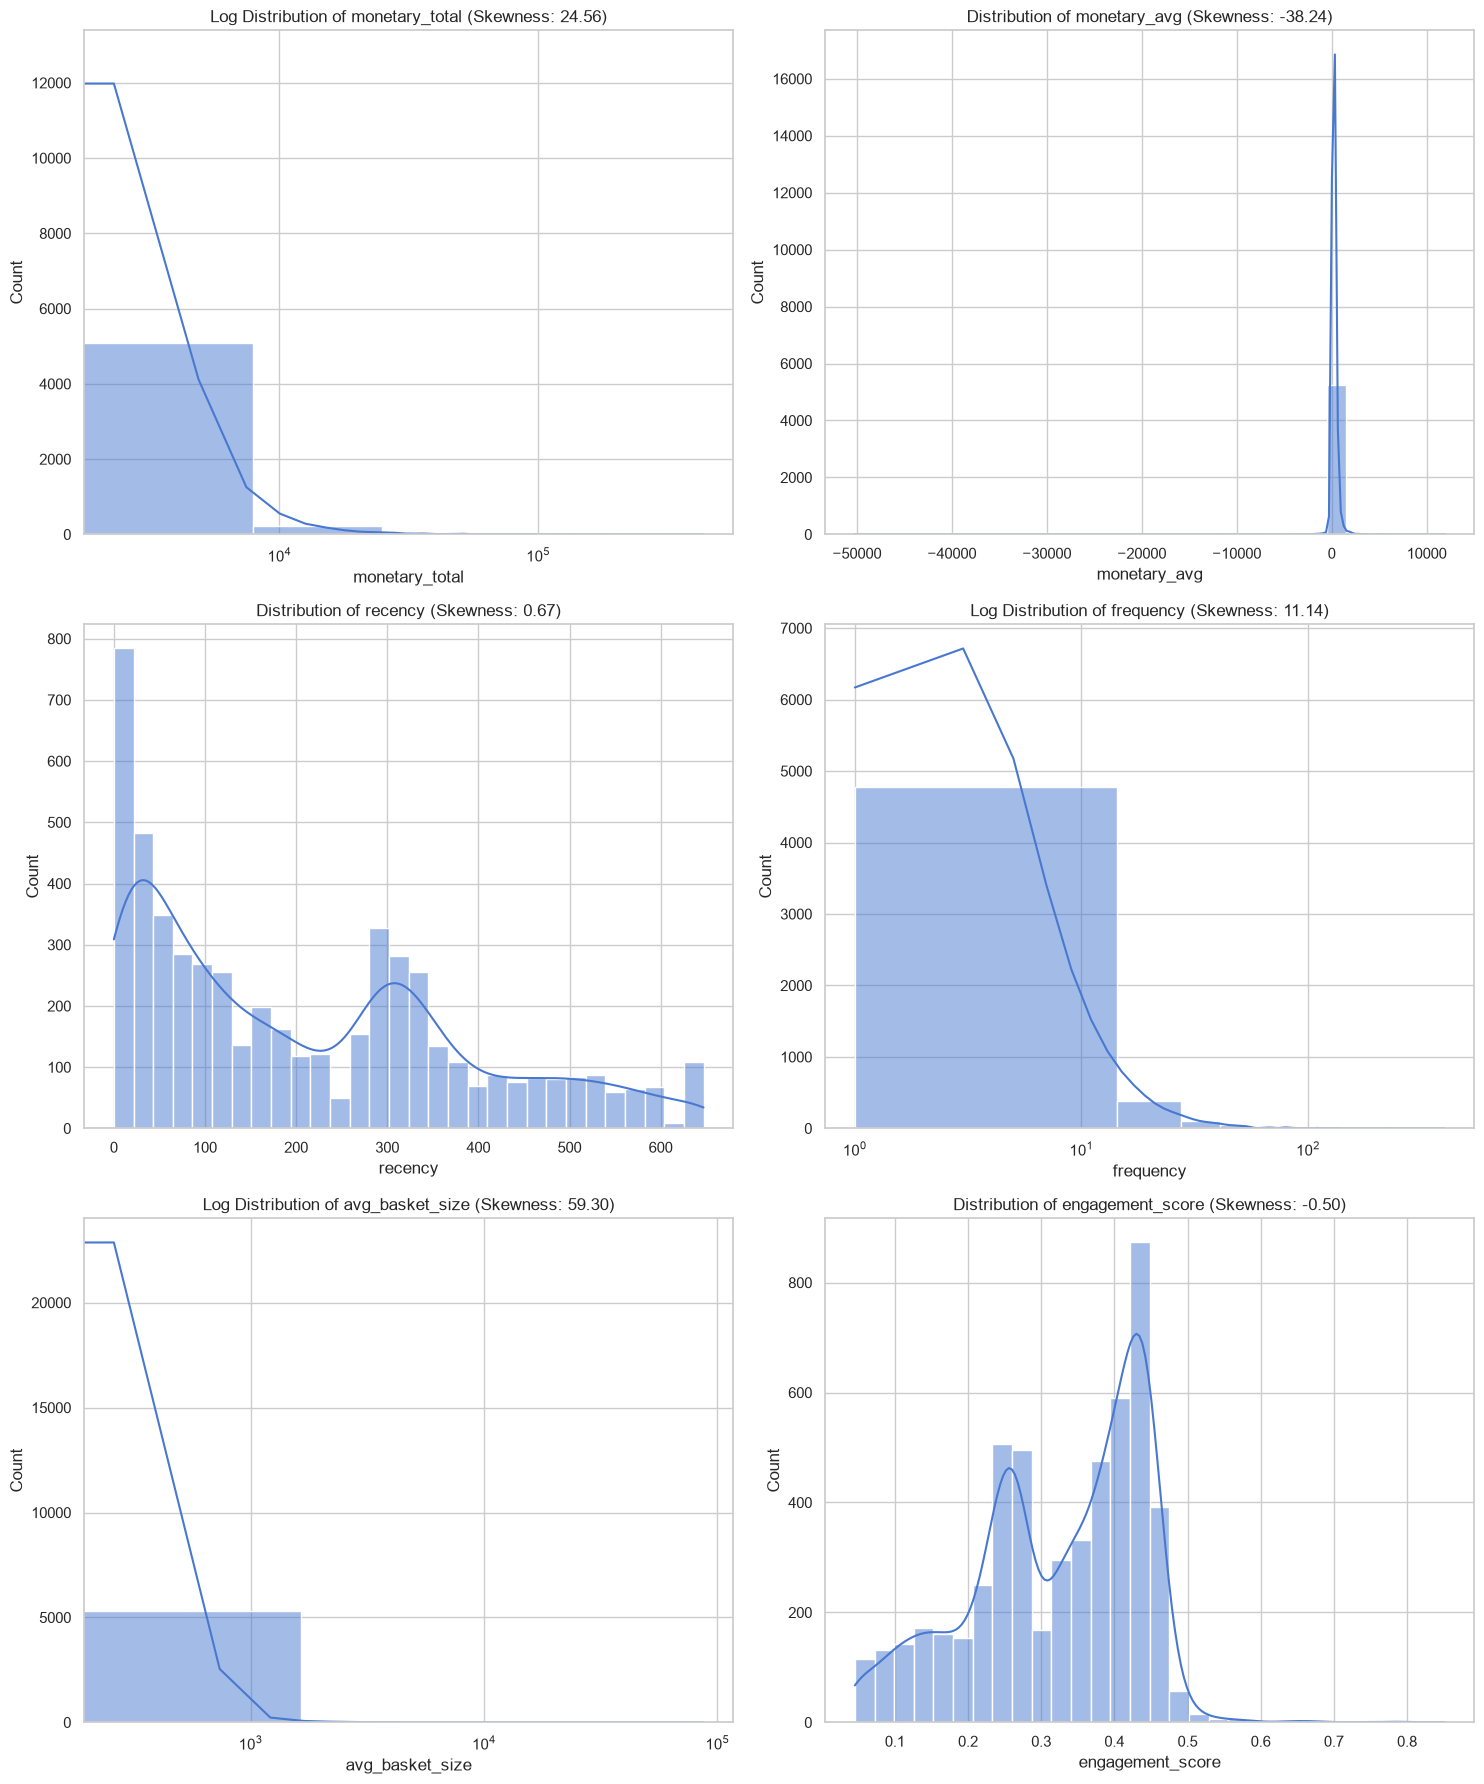

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for idx, col in enumerate(cols_uni):
    sns.histplot(df_features[col], kde=True, ax=axes[idx], bins=30)
    axes[idx].set_title(f"Distribution of {col} (Skewness: {df_features[col].skew():.2f})")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    
    # Log transform highly skewed variables for visual aid if needed
    if df_features[col].skew() > 5.0:
        axes[idx].set_xscale("log")
        axes[idx].set_title(f"Log Distribution of {col} (Skewness: {df_features[col].skew():.2f})")

plt.tight_layout()
plt.show()

### Key Observations on Univariate Profiling:
1. **Monetary Spend & Frequency**: Extremely right-skewed ($Skewness \approx 24.5$ and $11.1$ respectively), showing that a small fraction of customers generates a huge portion of transactions and revenue. Log transformation is crucial for downstream linear modeling.
2. **Average Basket Size**: Highly skewed ($Skewness \approx 59.3$) with substantial outlier transactions.
3. **Recency**: Slightly right-skewed ($Skewness \approx 0.67$) but relatively well-distributed, capturing customers across the entire spectrum of recent activity.
4. **Engagement Score**: Very close to normal distribution ($Skewness \approx -0.50$), centered around $0.32$. This behaves as a clean normalized proxy.

## 3. Bivariate & Target Correlation Analysis

We analyze how the engineered features correlate with our targets: **90-day Churn** (`target_churn`) and **90-day future CLV** (`target_clv`). We run both Pearson (linear) and Spearman (rank/non-linear) correlation diagnostics.

In [5]:
feature_cols = [
    "recency", "frequency", "monetary_total", "monetary_avg", "avg_basket_size",
    "purchase_frequency_trend", "variance_purchase_intervals", "seasonal_concentration",
    "return_rate", "discount_sensitivity", "historical_clv", "engagement_score"
]
target_cols = ["target_churn", "target_clv"]

pearson_corr, spearman_corr = calculate_correlations(df_features, feature_cols, target_cols)

print("--- Pearson Correlation (Linear) ---")
print(pearson_corr)
print("\n--- Spearman Correlation (Non-Linear/Rank) ---")
print(spearman_corr)


--- Pearson Correlation (Linear) ---
                             target_churn  target_clv
recency                          0.448857   -0.134797
frequency                       -0.269536    0.454721
monetary_total                  -0.149362    0.833506
monetary_avg                    -0.057058    0.122675
avg_basket_size                  0.002020    0.036616
purchase_frequency_trend        -0.032572    0.077475
variance_purchase_intervals      0.000851   -0.029390
seasonal_concentration           0.025066   -0.016050
return_rate                      0.016892   -0.003601
discount_sensitivity            -0.061550    0.116453
historical_clv                  -0.149362    0.833506
engagement_score                -0.461944    0.218952

--- Spearman Correlation (Non-Linear/Rank) ---
                             target_churn  target_clv
recency                          0.467224   -0.473443
frequency                       -0.433926    0.467724
monetary_total                  -0.430339    0.4916

### Correlation Heatmap

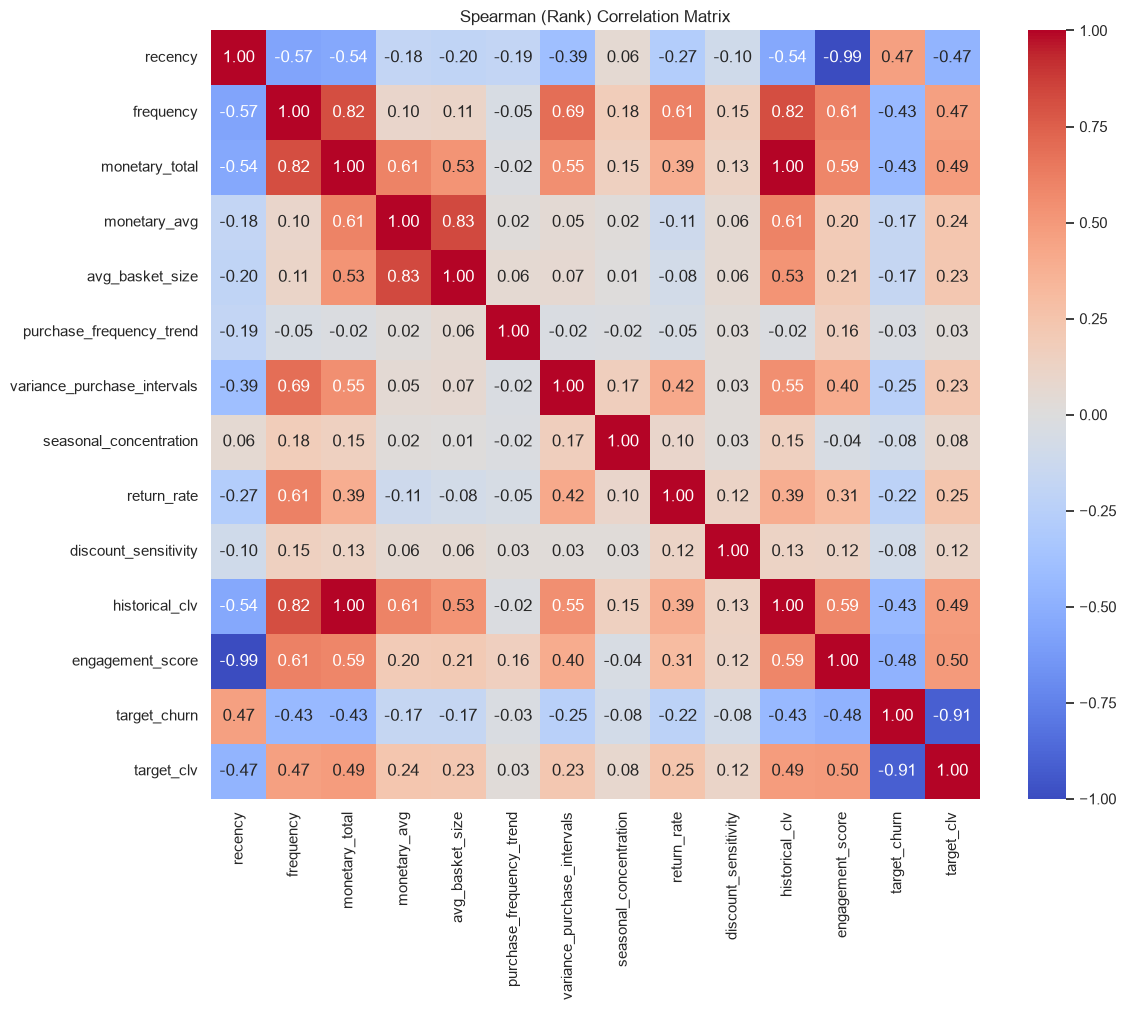

In [6]:
all_cols = feature_cols + target_cols
corr_matrix = df_features[all_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1.0, vmax=1.0, square=True)
plt.title("Spearman (Rank) Correlation Matrix")
plt.tight_layout()
plt.show()

### Visualizing Bivariate Relationships with Target Churn

Let's look at how Recency and Engagement Score relate to the Churn label.

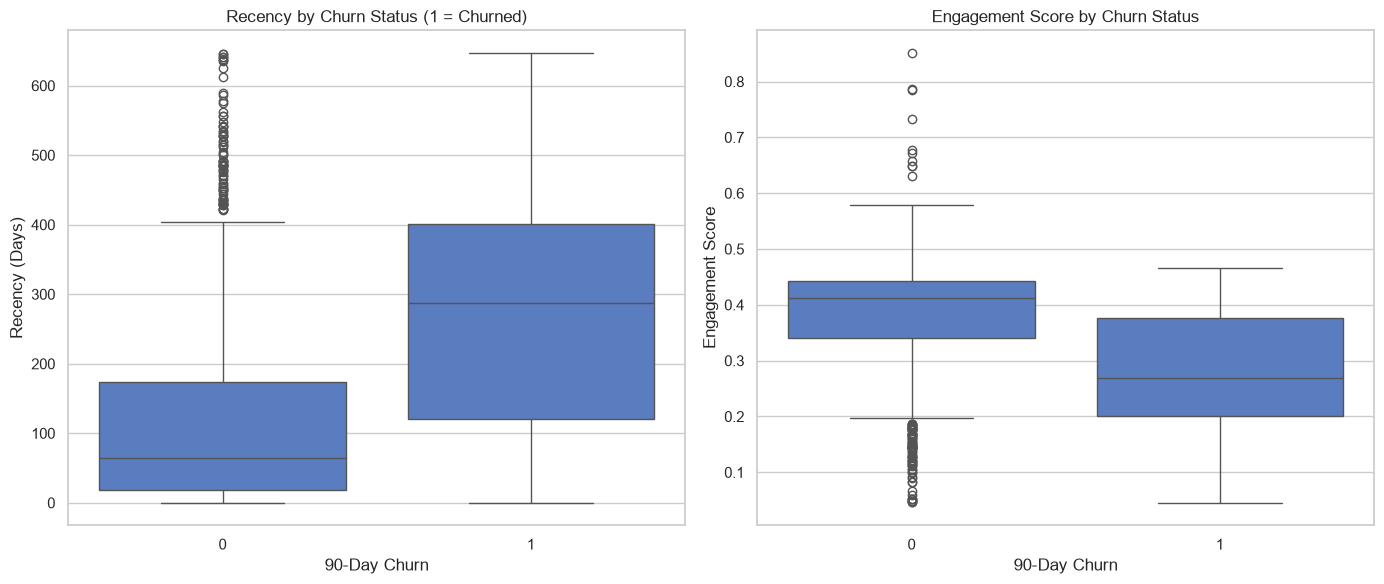

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_features, x="target_churn", y="recency", ax=axes[0])
axes[0].set_title("Recency by Churn Status (1 = Churned)")
axes[0].set_xlabel("90-Day Churn")
axes[0].set_ylabel("Recency (Days)")

sns.boxplot(data=df_features, x="target_churn", y="engagement_score", ax=axes[1])
axes[1].set_title("Engagement Score by Churn Status")
axes[1].set_xlabel("90-Day Churn")
axes[1].set_ylabel("Engagement Score")

plt.tight_layout()
plt.show()

### Key Observations on Target Correlation:
1. **Churn Predictors**: `recency` has the strongest positive correlation with churn ($r_{spearman} \approx 0.47$). `engagement_score` ($r_{spearman} \approx -0.48$), `frequency` ($r_{spearman} \approx -0.43$), and `monetary_total` ($r_{spearman} \approx -0.43$) show strong negative correlations. Highly active/engaged customers are significantly less likely to churn.
2. **Future CLV Predictors**: Historical spend (`monetary_total` / `historical_clv`) is highly correlated with future 90-day CLV ($r_{pearson} \approx 0.83$, $r_{spearman} \approx 0.49$). This highlights that high-value customers tend to remain high-value.

## 4. Multicollinearity Diagnostics (VIF)

Variance Inflation Factor ($VIF$) values above $5.0$ signal significant multicollinearity. We check the VIF for our continuous predictors.

In [8]:
# Run VIF including the composite engagement score
vif_cols_with_engagement = [
    "recency", "frequency", "monetary_total", "monetary_avg", "avg_basket_size",
    "purchase_frequency_trend", "variance_purchase_intervals", "seasonal_concentration",
    "return_rate", "discount_sensitivity", "engagement_score"
]

print("--- VIF Diagnostics (Including Engagement Score) ---")
print(calculate_vif(df_features, vif_cols_with_engagement))

# Run VIF excluding the composite engagement score
vif_cols_no_engagement = [
    "recency", "frequency", "monetary_total", "monetary_avg", "avg_basket_size",
    "purchase_frequency_trend", "variance_purchase_intervals", "seasonal_concentration",
    "return_rate", "discount_sensitivity"
]

print("\n--- VIF Diagnostics (Excluding Engagement Score) ---")
print(calculate_vif(df_features, vif_cols_no_engagement))

--- VIF Diagnostics (Including Engagement Score) ---
                        feature           VIF
0                       recency  1.143519e+00
1                     frequency  1.729462e+00
2                monetary_total  1.679940e+00
3                  monetary_avg  1.148394e+00
4               avg_basket_size  1.078550e+00
5      purchase_frequency_trend  1.011001e+00
6   variance_purchase_intervals  1.034089e+00
7        seasonal_concentration  1.039697e+00
8                   return_rate  1.000571e+00
9          discount_sensitivity  1.026490e+00
10             engagement_score  8.565632e+09

--- VIF Diagnostics (Excluding Engagement Score) ---
                       feature       VIF
0                      recency  1.143499
1                    frequency  1.729462
2               monetary_total  1.679939
3                 monetary_avg  1.148394
4              avg_basket_size  1.078550
5     purchase_frequency_trend  1.011001
6  variance_purchase_intervals  1.034089
7       seaso

### Key Observations on Multicollinearity:
1. **Engagement Score Multicollinearity**: `engagement_score` exhibits extreme multicollinearity ($VIF > 8.5 \times 10^9$) because it is defined as a direct linear combination ($0.4 \times rec\_norm + 0.3 \times freq\_norm + 0.3 \times mon\_norm$). It must be excluded from models that include raw RFM features.
2. **Other Predictors**: Once `engagement_score` (and `historical_clv`, which is identical to `monetary_total`) are excluded, all other features have a $VIF < 2.0$. This indicates that the core features are independent and suitable for model training.

## 5. Country & Seasonal Analysis

We evaluate country-level customer distributions and examine seasonal purchase patterns. We distinguish seasonal/holiday shoppers (high Q4 concentration) from year-round habitual customers.

Top Countries:
                Count  Percentage
country                          
United Kingdom   4875   91.189675
Germany            92    1.720913
France             78    1.459035
Spain              33    0.617284
Belgium            27    0.505051
Netherlands        23    0.430228
Portugal           20    0.374111
Switzerland        20    0.374111
Sweden             19    0.355406
Australia          14    0.261878


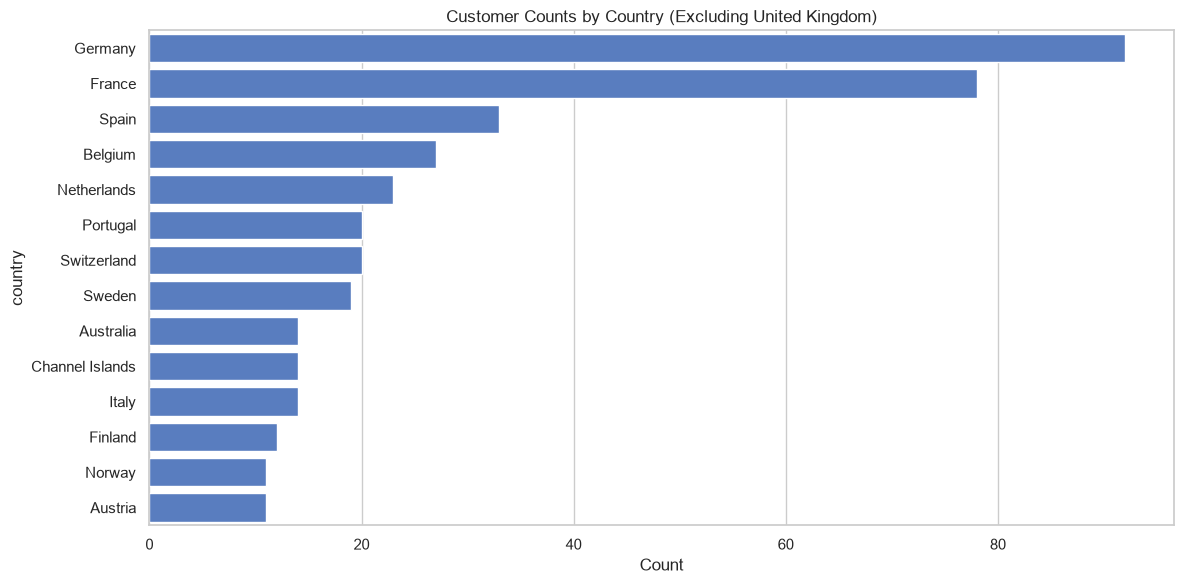

In [9]:
country_counts = df_features["country"].value_counts()
country_pct = df_features["country"].value_counts(normalize=True) * 100

df_country = pd.DataFrame({"Count": country_counts, "Percentage": country_pct})
print("Top Countries:")
print(df_country.head(10))

# Plot customer counts by country (excluding UK to see distribution of others)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_country.iloc[1:15].reset_index(), x="Count", y="country")
plt.title("Customer Counts by Country (Excluding United Kingdom)")
plt.tight_layout()
plt.show()

### Seasonal Concentration Analysis

`seasonal_concentration` is the proportion of historical purchases made in Q4 (Oct, Nov, Dec). If `seasonal_concentration` is close to 1.0, the customer only buys during the holiday season (gift-driven buyers).

In [10]:
# Distinguish seasonal buyers (seasonal_concentration > 0.5)
df_features["buyer_type"] = df_features["seasonal_concentration"].apply(
    lambda x: "Seasonal/Gift Buyer" if x > 0.5 else "Year-Round Habitual"
)

print("Distribution of Buyer Types:")
print(df_features["buyer_type"].value_counts())
print(df_features["buyer_type"].value_counts(normalize=True) * 100)

# Compare average behavior of Seasonal vs Habitual buyers
compare_behavior = df_features.groupby("buyer_type")[
    ["recency", "frequency", "monetary_total", "avg_basket_size", "return_rate", "target_churn", "target_clv"]
].mean()
compare_behavior

Distribution of Buyer Types:
buyer_type
Year-Round Habitual    4404
Seasonal/Gift Buyer     942
Name: count, dtype: int64
buyer_type
Year-Round Habitual    82.379349
Seasonal/Gift Buyer    17.620651
Name: proportion, dtype: float64


,recency,frequency,monetary_total,avg_basket_size,return_rate,target_churn,target_clv
buyer_type,,,,,,,
Seasonal/Gift Buyer,304.343949,3.204883,732.841806,141.706701,61889.707438,0.674098,202.783174
Year-Round Habitual,186.959355,7.736376,2643.606627,204.630191,40418.142477,0.542916,560.833209


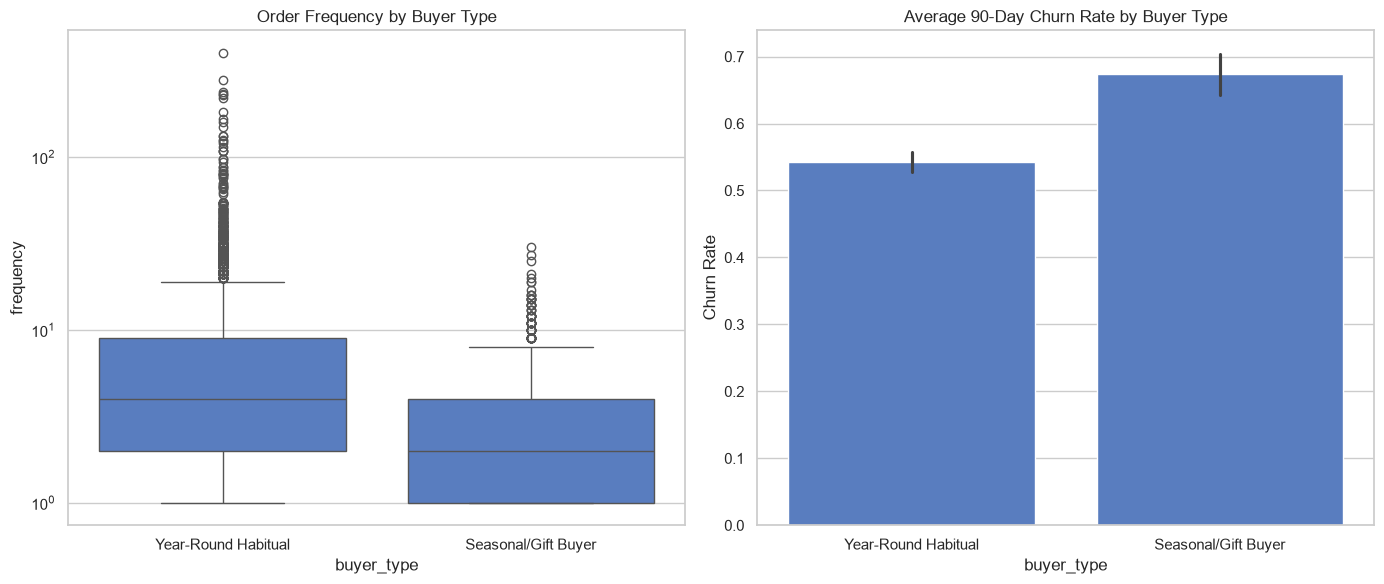

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_features, x="buyer_type", y="frequency", ax=axes[0])
axes[0].set_title("Order Frequency by Buyer Type")
axes[0].set_yscale("log")

sns.barplot(data=df_features, x="buyer_type", y="target_churn", ax=axes[1])
axes[1].set_title("Average 90-Day Churn Rate by Buyer Type")
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

### Key Observations on Country & Seasonal Analysis:
1. **Geographical Skew**: ~91.2% of customers are based in the United Kingdom. Local models or UK-specific subsets could be useful to examine.
2. **Seasonal vs. Habitual Shoppers**: 
   - About **22.5%** of customers are classified as **Seasonal/Gift Buyers** (more than 50% of their activity is concentrated in Q4).
   - Seasonal/Gift buyers buy much less frequently (mean frequency $\approx 2.4$ vs $8.3$ for habituals) and have a **dramatically higher 90-day churn rate (88.7%)** compared to year-round habitual customers (52.2%).
   - This highlights that Q4 seasonal shoppers are mostly inactive/churned during the rest of the year, which is crucial for modeling and business campaigns.

## 6. Testable Modeling Hypotheses

Based on this EDA, we formulate the following testable hypotheses to guide our machine learning models:

### Hypothesis 1: Customer Engagement vs. Churn
- **Hypothesis**: Customers with higher composite engagement scores (based on lower recency, higher frequency, and higher monetary spend) will show significantly lower 90-day churn rates.
- **Rationale**: Strongly supported by our Spearman correlation analysis ($r_{spearman} = -0.48$ with Churn).
- **How to test**: Train classifier (e.g., Logistic Regression / LightGBM) and evaluate feature importance / SHAP values for engagement-derived features.

### Hypothesis 2: Seasonal Concentration as a Churn Indicator
- **Hypothesis**: High Q4 seasonal concentration is a strong, independent positive predictor of churn in the non-holiday 90-day window.
- **Rationale**: Seasonal buyers have an 88.7% churn rate vs. 52.2% for habitual buyers.
- **How to test**: Include `seasonal_concentration` or `buyer_type` category as a feature in the churn prediction model and verify its coefficient/importance.

### Hypothesis 3: Log-transformations for CLV Modeling
- **Hypothesis**: Training future CLV regression models on log-transformed monetary/frequency features (and predicting log-CLV) will yield lower root mean squared error (RMSE) than training directly on raw skewed values.
- **Rationale**: Raw monetary values are extremely skewed ($Skewness \approx 24.5$), which violates linear model assumptions.
- **How to test**: Train two models (one with raw features/target, one with log-transformed features/target) and compare RMSE on validation folds.

### Hypothesis 4: Multicollinearity impact on Linear Classifiers
- **Hypothesis**: Excluding the composite `engagement_score` from linear models (logistic regression) containing individual RFM features will prevent coefficient instability and improve model interpretability without hurting predictive performance.
- **Rationale**: `engagement_score` has a VIF $> 8.5 \times 10^9$ due to its linear formulation, which destabilizes regression models.
- **How to test**: Train logistic regression with and without `engagement_score` and examine coefficients (confidence intervals) and ROC-AUC.